Objective

Build a machine learning model to classify breast tumors as:

Malignant (M) – Cancerous

Benign (B) – Non-cancerous

Business Importance

Early detection of malignant tumors:

Saves lives

Reduces treatment cost

Improves survival rates

In medical diagnosis, False Negatives are extremely dangerous.
So, Recall for Malignant class is critical.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,precision_score,recall_score,roc_auc_score,matthews_corrcoef,roc_curve,auc
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

In [2]:
df = pd.read_csv(r"E:\Besant_Technology\Data Science\Classification\breast-cancer.csv")
df.head(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Diagnosis ---------- M - Malignant(Cancerous) B - Benign (Non - Cancerous)

In [3]:
df = df.drop(columns = ['id'], axis =1)

In [4]:
df.index

RangeIndex(start=0, stop=569, step=1)

In [5]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [6]:
#df.dtypes

In [7]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

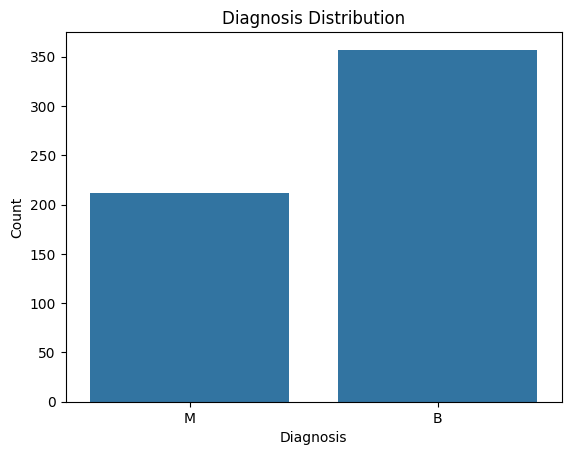

In [11]:
sns.countplot(x = 'diagnosis', data = df)
plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

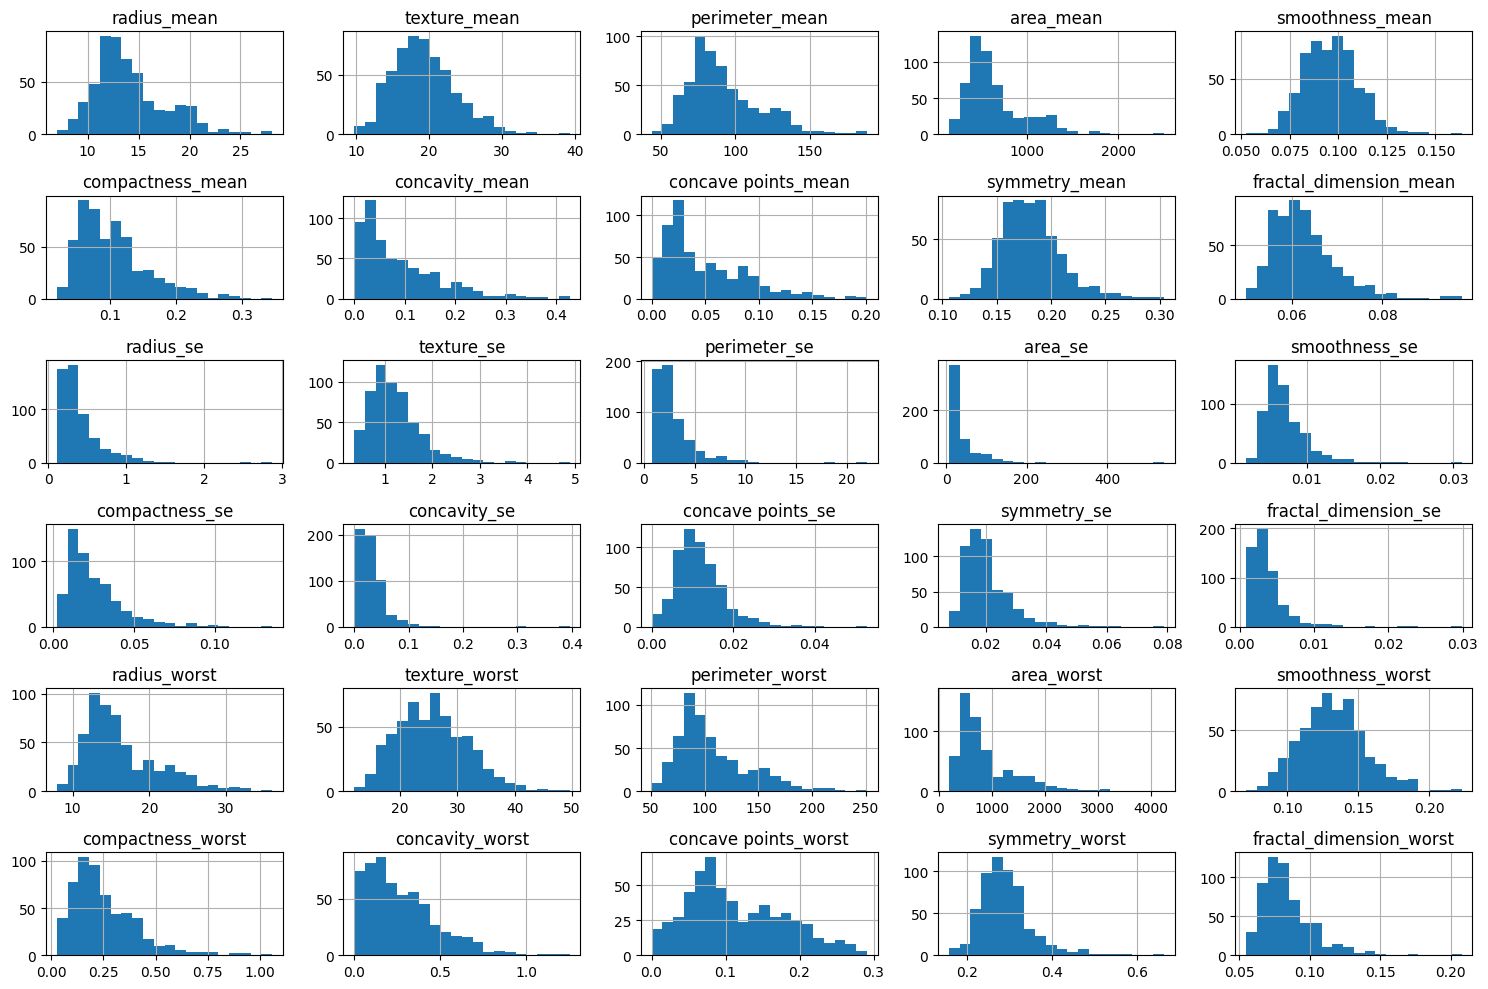

In [12]:
df.hist(bins=20, figsize=(15,10))
plt.tight_layout()
plt.show()

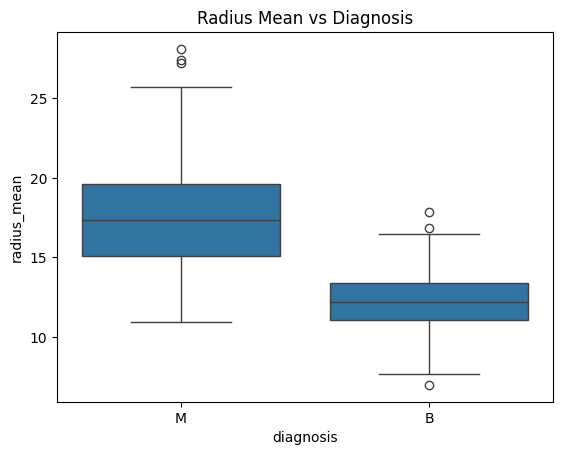

In [13]:
sns.boxplot(x='diagnosis', y='radius_mean', data=df)
plt.title("Radius Mean vs Diagnosis")
plt.show()

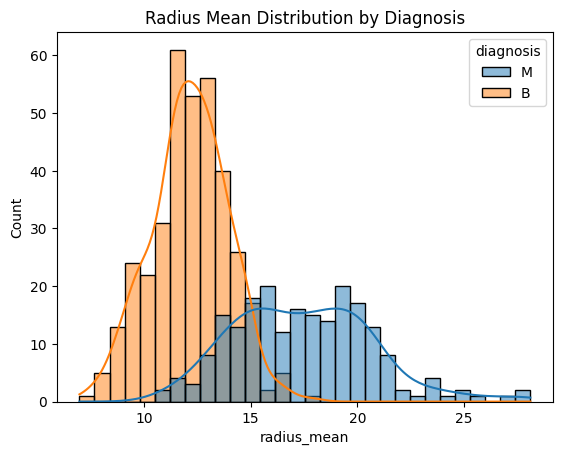

In [14]:
plt.figure()
sns.histplot(data=df, x='radius_mean', hue='diagnosis', kde=True, bins=30)
plt.title('Radius Mean Distribution by Diagnosis')
plt.show()

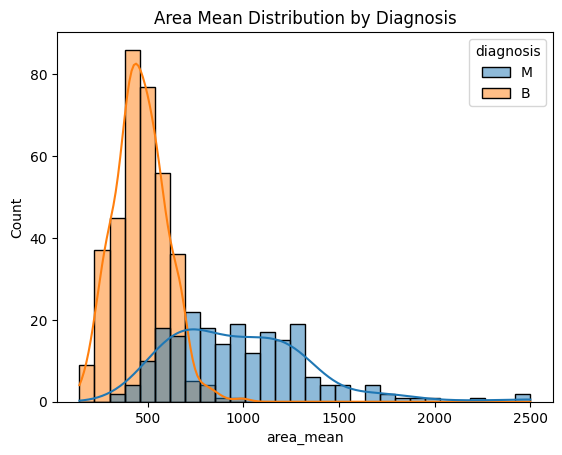

In [15]:
plt.figure()
sns.histplot(data=df, x='area_mean', hue='diagnosis', kde=True, bins=30)
plt.title('Area Mean Distribution by Diagnosis')
plt.show()

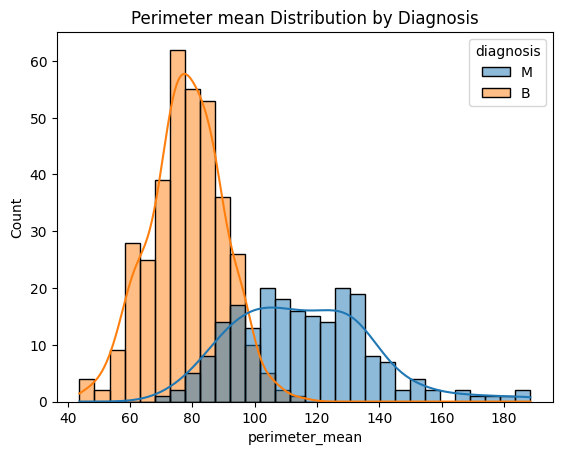

In [17]:
#plt.figure()n - 1
sns.histplot(data=df, x='perimeter_mean', hue='diagnosis', kde=True, bins=30)
plt.title('Perimeter mean Distribution by Diagnosis')
plt.show()

In [18]:
cor = df.select_dtypes(['int', 'float']).corr()
cor

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
radius_mean,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413
fractal_dimension_mean,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,-0.253691,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297


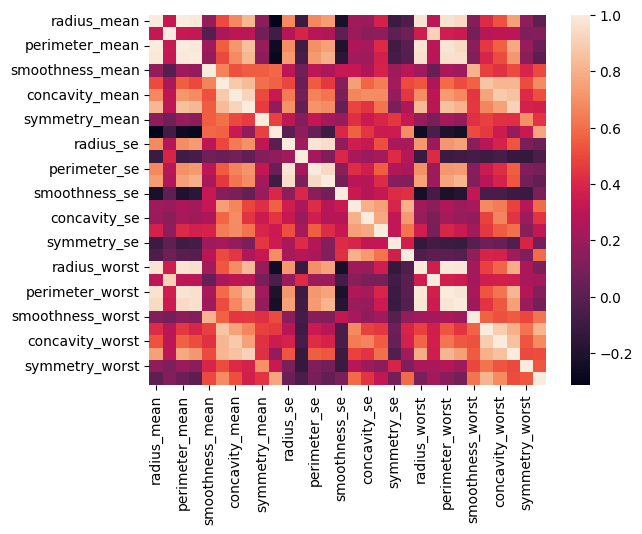

In [19]:
sns.heatmap(cor)
plt.show()

Feature Engineering

Convert Categorical data into numerical data

In [20]:
df['diagnosis'].unique()

array(['M', 'B'], dtype=object)

In [ ]:
diag = {
    'M' : 1,
    'B' :0
}
df['diagnosis'] = df['diagnosis'].map(diag)
df['diagnosis'].head(2)

0    1
1    1
Name: diagnosis, dtype: int64

In [22]:
df['diagnosis'].unique()

array([1, 0])

In [ ]:
#df.dtypes

In [23]:
# Relation between diagnosis and other things.
df.corr()['diagnosis'].sort_values(ascending=False)

diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

In [24]:
X = df.drop('diagnosis', axis = 1)
y = df['diagnosis']

In [26]:
outlier_counts = {}
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    Q1 = np.percentile(df[col], 25)
    Q3 = np.percentile(df[col], 75)
    IQR = Q3 - Q1
    
    if IQR == 0:
        outlier_counts[col] = 0
        continue
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    count = np.sum((df[col] < lower) | (df[col] > upper))
    outlier_counts[col] = count

# Convert to DataFrame for readability
outlier_df = (
    pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Outlier_Count'])
      .sort_values(by='Outlier_Count', ascending=False)
)
#print(outlier_df)

Since most of the columns are having outlier the above data is medical data so outlier is something that can happen so we cann't remove half of the data in such case we can go for Robust scaling. 

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)

In [28]:
# numeric_cols = df.select_dtypes(include=np.number).columns
r = RobustScaler()
X_train_scaled = r.fit_transform(X_train)
X_test_scaled = r.transform(X_test)

In [29]:
knn_base = KNeighborsClassifier()
knn_base.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [30]:
y_pred = knn_base.predict(X_test_scaled)
y_pred_prob = knn_base.predict_proba(X_test_scaled)[:,1]

In [ ]:
#y_pred_prob

In [31]:
accuracy_score(y_pred = y_pred, y_true = y_test)

0.9532163742690059

In [32]:
estimator = KNeighborsClassifier()
param_grid = {
    "n_neighbors" : list(range(1,100,2)),
    "metric" : ['cityblock', 'euclidean', 'manhattan', 'minkowski']
}
cv = 5

In [33]:
grid = GridSearchCV(estimator = estimator, param_grid = param_grid, cv = cv)
grid.fit(X_train_scaled, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['cityblock', 'euclidean', ...], 'n_neighbors': [1, 3, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,5


In [ ]:
grid.best_params_, grid.best_score_

({'metric': 'cityblock', 'n_neighbors': 7}, np.float64(0.9622784810126582))

In [34]:
knn_grid = KNeighborsClassifier(n_neighbors = 7, metric = 'cityblock')
knn_grid.fit(X, y)
y_pred_grid = knn_grid.predict(X_test_scaled)
score_grid = accuracy_score(y_test, y_pred)
score_grid

c:\Users\baran\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


0.9532163742690059

In [35]:
rand = RandomizedSearchCV(estimator = estimator, param_distributions = param_grid, cv = cv)
rand.fit(X_train_scaled, y_train)

,estimator,KNeighborsClassifier()
,param_distributions,"{'metric': ['cityblock', 'euclidean', ...], 'n_neighbors': [1, 3, ...]}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [36]:
rand.best_params_, rand.best_score_

({'n_neighbors': 13, 'metric': 'euclidean'}, np.float64(0.9445569620253165))

In [37]:
knn_rand = KNeighborsClassifier(n_neighbors = 13, metric = 'euclidean')
knn_rand.fit(X,y)
y_pred_rand = knn_rand.predict(X_test_scaled)
knn_rand_score = accuracy_score(y_test, y_pred)
knn_rand_score

c:\Users\baran\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


0.9532163742690059

In [38]:
print(confusion_matrix(y_test, y_pred))

[[110   3]
 [  5  53]]


In [39]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96       113
           1       0.95      0.91      0.93        58

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.95       171
weighted avg       0.95      0.95      0.95       171



In [40]:
y_pred_prob = rand.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
roc_auc

0.9948123283490997

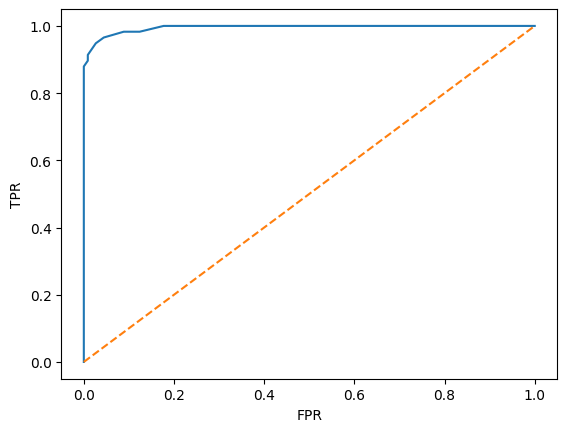

In [41]:
plt.plot(fpr,tpr, label = f"KNN (AUC= {roc_auc : .3f})")
plt.plot([0,1],[0,1], linestyle = "--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

The blue line more closure to 1 the better the model it is.